### Expérience 9 : Classification des lésions cutanées 



- **Dataset** : HAM10000 ("Human Against Machine with 10000 training images")  
 
- **Architecture** : ResNet
 
- **Optimisateur** : RMSprop  


- **Fonction de perte** : Dice Loss  




# Chargement des Bibliothèques Python et Initialisation

***Nous chargeons toutes les bibliothèques nécessaires pour le projet de din module Fouille des données***

In [1]:
%matplotlib inline
# Bibliothèques Python
import os, cv2,itertools
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
from glob import glob
from PIL import Image

# Bibliothèques PyTorch
import torch
from torch import optim,nn
from torch.autograd import Variable
from torch.utils.data import DataLoader,Dataset
from torchvision import models,transforms

# Bibliothèques scikit-learn
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Assurer la reproductibilité des résultats
np.random.seed(10)
torch.manual_seed(10)
torch.cuda.manual_seed(10)

# Vérification du contenu du répertoire
print(os.listdir('/kaggle/input/'))

['skin-cancer-mnist-ham10000']


In [2]:
import torch

# Après chaque époque, videz le cache
torch.cuda.empty_cache()

# Chargement et Prétraitement des Images

In [3]:
# Vérification du contenu du répertoire d'images
print(os.listdir('../input/skin-cancer-mnist-ham10000'))

['hmnist_8_8_RGB.csv', 'hmnist_28_28_RGB.csv', 'HAM10000_images_part_1', 'ham10000_images_part_1', 'hmnist_8_8_L.csv', 'HAM10000_images_part_2', 'ham10000_images_part_2', 'hmnist_28_28_L.csv', 'HAM10000_metadata.csv']


In [4]:
# Définir le répertoire des données
data_dir = '../input/skin-cancer-mnist-ham10000'

# Récupérer les chemins des images (fichiers .jpg)
all_image_path = glob(os.path.join(data_dir, '*', '*.jpg'))

# Créer un dictionnaire pour associer l'ID de l'image au chemin
imageid_path_dict = {os.path.splitext(os.path.basename(x))[0]: x for x in all_image_path}

# Dictionnaire des types de lésions cutanées
lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'dermatofibroma',
    'bkl': 'Benign keratosis-like lesions ',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

In [5]:
def compute_img_mean_std(image_paths):
    """
        Calcul de la moyenne et de l'écart-type des trois canaux (R, G, B) pour l'ensemble du dataset.
        Avant cela, les images sont normalisées de la plage 0-255 à 0-1.
    """

    img_h, img_w = 224, 224
    imgs = []
    means, stdevs = [], []

    for i in tqdm(range(len(image_paths))):
        img = cv2.imread(image_paths[i])
        img = cv2.resize(img, (img_h, img_w))
        imgs.append(img)

    imgs = np.stack(imgs, axis=3)
    print(imgs.shape)
    
    # Normalisation des valeurs des pixels de [0, 255] à [0, 1]
    imgs = imgs.astype(np.float32) / 255.

    # Calcul de la moyenne et de l'écart-type pour chaque canal
    for i in range(3):
        pixels = imgs[:, :, i, :].ravel() 
        means.append(np.mean(pixels))
        stdevs.append(np.std(pixels))

    means.reverse()  # BGR --> RGB
    stdevs.reverse()

    print("normMean = {}".format(means))
    print("normStd = {}".format(stdevs))
    return means,stdevs

In [6]:
# Valeurs moyennes et écart-types normalisés pour les canaux R, G, B
norm_mean = [0.7630392, 0.5456477, 0.57004845]
norm_std = [0.1409286, 0.15261266, 0.16997074]

In [7]:
# Chargement des métadonnées
df_original = pd.read_csv(os.path.join(data_dir, 'HAM10000_metadata.csv'))

# Ajout du chemin d'accès à chaque image
df_original['path'] = df_original['image_id'].map(imageid_path_dict.get)

# Ajout du type de lésion cutanée à partir du dictionnaire
df_original['cell_type'] = df_original['dx'].map(lesion_type_dict.get)

# Conversion du type de lésion en indices numériques
df_original['cell_type_idx'] = pd.Categorical(df_original['cell_type']).codes

df_original.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,cell_type,cell_type_idx
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,../input/skin-cancer-mnist-ham10000/ham10000_i...,Benign keratosis-like lesions,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,../input/skin-cancer-mnist-ham10000/ham10000_i...,Benign keratosis-like lesions,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,../input/skin-cancer-mnist-ham10000/ham10000_i...,Benign keratosis-like lesions,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,../input/skin-cancer-mnist-ham10000/ham10000_i...,Benign keratosis-like lesions,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,../input/skin-cancer-mnist-ham10000/ham10000_i...,Benign keratosis-like lesions,2


In [8]:
# Regroupement par 'lesion_id' et comptage des occurrences
df_undup = df_original.groupby('lesion_id').count()

# Filtrer les 'lesion_id' qui ont seulement une image associée
df_undup = df_undup[df_undup['image_id'] == 1]

# Réinitialisation de l'index pour simplifier l'accès
df_undup.reset_index(inplace=True)

df_undup.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,cell_type,cell_type_idx
0,HAM_0000001,1,1,1,1,1,1,1,1,1
1,HAM_0000003,1,1,1,1,1,1,1,1,1
2,HAM_0000004,1,1,1,1,1,1,1,1,1
3,HAM_0000007,1,1,1,1,1,1,1,1,1
4,HAM_0000008,1,1,1,1,1,1,1,1,1


In [9]:
# Fonction pour identifier les doublons dans les lésions
def get_duplicates(x):
    unique_list = list(df_undup['lesion_id'])
    if x in unique_list:
        return 'unduplicated'
    else:
        return 'duplicated'

# Création d'une nouvelle colonne qui est une copie de la colonne 'lesion_id'
df_original['duplicates'] = df_original['lesion_id']

# Application de la fonction pour marquer les doublons
df_original['duplicates'] = df_original['duplicates'].apply(get_duplicates)

df_original.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,cell_type,cell_type_idx,duplicates
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,../input/skin-cancer-mnist-ham10000/ham10000_i...,Benign keratosis-like lesions,2,duplicated
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,../input/skin-cancer-mnist-ham10000/ham10000_i...,Benign keratosis-like lesions,2,duplicated
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,../input/skin-cancer-mnist-ham10000/ham10000_i...,Benign keratosis-like lesions,2,duplicated
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,../input/skin-cancer-mnist-ham10000/ham10000_i...,Benign keratosis-like lesions,2,duplicated
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,../input/skin-cancer-mnist-ham10000/ham10000_i...,Benign keratosis-like lesions,2,duplicated


In [10]:
# Comptage des valeurs dans la colonne 'duplicates' pour savoir combien de doublons et non-doublons il y a
df_original['duplicates'].value_counts().reset_index(name='count')

,duplicates,count
0,unduplicated,5514
1,duplicated,4501


In [11]:
# Filtrer les lésions qui sont marquées comme 'unduplicated'
df_undup = df_original[df_original['duplicates'] == 'unduplicated']
df_undup.shape

(5514, 11)

In [12]:
y = df_undup['cell_type_idx']

# Création d'un ensemble de validation en utilisant train_test_split
_, df_val = train_test_split(df_undup, test_size=0.2, random_state=101, stratify=y)

# Affichage de la forme de l'ensemble de validation pour vérifier sa taille
df_val.shape

(1103, 11)

In [13]:
# Vérification de la répartition des classes dans l'ensemble de validation
df_val['cell_type_idx'].value_counts().reset_index(name='count')

,cell_type_idx,count
0,4,883
1,2,88
2,6,46
3,1,35
4,0,30
5,5,13
6,3,8


In [14]:
def get_val_rows(x):
    # create a list of all the lesion_id's in the val set
    val_list = list(df_val['image_id'])
    if str(x) in val_list:
        return 'val'
    else:
        return 'train'

# Identify train and val rows
# Create a new colum that is a copy of the image_id column
df_original['train_or_val'] = df_original['image_id']
# Apply the function to this new column
df_original['train_or_val'] = df_original['train_or_val'].apply(get_val_rows)
# Filter out training rows
df_train = df_original[df_original['train_or_val'] == 'train']
print(len(df_train))
print(len(df_val))

8912
1103


In [15]:
df_train['cell_type_idx'].value_counts().reset_index(name='count')

,cell_type_idx,count
0,4,5822
1,6,1067
2,2,1011
3,1,479
4,0,297
5,5,129
6,3,107


In [16]:
df_val['cell_type'].value_counts().reset_index(name='count')

,cell_type,count
0,Melanocytic nevi,883
1,Benign keratosis-like lesions,88
2,dermatofibroma,46
3,Basal cell carcinoma,35
4,Actinic keratoses,30
5,Vascular lesions,13
6,Dermatofibroma,8


In [17]:
import torch

# Vérifiez si CUDA (GPU) est disponible
cuda_available = torch.cuda.is_available()
print(f"CUDA is available: {cuda_available}")

# Si le GPU est disponible, utilisez-le, sinon utilisez le CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Affichez le nom du GPU, si disponible
if cuda_available:
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU found.")

# Exemple de tensor déplacé vers le GPU
tensor = torch.randn(3, 3).to(device)
print(f"Tensor on device: {tensor.device}")


CUDA is available: True
GPU Name: Tesla P100-PCIE-16GB
Tensor on device: cuda:0


# Augmentation des Images

***Nous équilibrons les classes par augmentation des données***

In [18]:
import pandas as pd

# Initialiser les taux d'augmentation souhaités
data_aug_rate = [15, 10, 5, 50, 0, 40, 5]

# Calculer le nombre maximum d'exemples parmi toutes les classes (pour le but d'équilibrage)
max_size = df_train['cell_type'].value_counts().max()

# Créer un DataFrame pour enregistrer les nouvelles données augmentées
augmented_data = []

# Boucle sur chaque classe et augmenter de manière équilibrée
for i in range(7):
    # Récupérer le sous-ensemble de données pour chaque classe
    class_data = df_train[df_train['cell_type_idx'] == i]
    
    # Calculer le nombre d'exemples à augmenter pour atteindre la taille cible
    target_size = max_size  # ou une taille cible définie manuellement
    current_size = len(class_data)
    augmentation_factor = (target_size // current_size)  # combien de fois multiplier les données de la classe
    
    # Si augmentation nécessaire
    if augmentation_factor > 1:
        augmented_class_data = pd.concat([class_data] * augmentation_factor, ignore_index=True)
        augmented_data.append(augmented_class_data)

# Concaténer toutes les classes augmentées avec les données d'origine
df_train_augmented = pd.concat([df_train] + augmented_data, ignore_index=True)

# Vérifier les nouvelles valeurs de 'cell_type' après augmentation
print(df_train_augmented['cell_type'].value_counts())

cell_type
dermatofibroma                    6402
Basal cell carcinoma              6227
Benign keratosis-like lesions     6066
Actinic keratoses                 5940
Vascular lesions                  5934
Dermatofibroma                    5885
Melanocytic nevi                  5822
Name: count, dtype: int64


In [19]:
# Split the test set again in a validation set and a true test set:
df_val, df_test = train_test_split(df_val, test_size=0.5)
df_train = df_train.reset_index()
df_val = df_val.reset_index()
df_test = df_test.reset_index()

print(len(df_test))
df_test['cell_type'].value_counts()

552


cell_type
Melanocytic nevi                  444
Benign keratosis-like lesions      47
dermatofibroma                     20
Basal cell carcinoma               15
Actinic keratoses                  12
Vascular lesions                    8
Dermatofibroma                      6
Name: count, dtype: int64

# Modèle de Réseaux de Neurones (ResNet)

In [20]:
# Cette fonction ajuste les paramètres de chaque couche d'un modèle en fonction de si l'on souhaite effectuer
# feature_extracting = False signifie fine-tuning complet (toutes les couches sont entraînables)
# feature_extracting = True signifie extraction de caractéristiques (seule la dernière couche est entraînable)
def set_parameter_requires_grad(model, feature_extracting):
    if feature_extracting:
        for param in model.parameters():
            param.requires_grad = False


In [21]:
# Fonction pour initialiser le modèle
def initialize_model(model_name, num_classes, feature_extract, use_pretrained=True):
    # Initialisation des variables pour le modèle et la taille d'entrée
    model_ft = None
    input_size = 0

    # Vérifier si le modèle demandé est 'resnet'
    if model_name == "resnet":
        """ Choix parmi les modèles ResNet: ResNet18, ResNet34, ResNet50, ResNet101 """
        
        # Charger le modèle ResNet50 avec des poids pré-entraînés (ImageNet par défaut)
        model_ft = models.resnet50(pretrained=use_pretrained)

        # Fonction pour geler ou ajuster les paramètres du modèle selon l'option 'feature_extract'
        set_parameter_requires_grad(model_ft, feature_extract)

        # Obtenir la taille des entrées de la couche 'fc' (dernière couche)
        num_ftrs = model_ft.fc.in_features

        # Remplacer la couche 'fc' pour l'adapter au nombre de classes spécifié
        model_ft.fc = nn.Linear(num_ftrs, num_classes)

        # Définir la taille d'entrée attendue par le modèle
        input_size = 224  # Pour ResNet, les images doivent être redimensionnées à 224x224 pixels

    else:
        # Si le modèle spécifié n'est pas supporté, afficher un message d'erreur et arrêter l'exécution
        print("Nom du modèle invalide, sortie...")
        exit()

    # Retourner le modèle initialisé et la taille d'entrée
    return model_ft, input_size

In [22]:
import torch

# Paramètres du modèle
model_name = "resnet"  # Choix du modèle (ici ResNet)
num_classes = 7  # Nombre de classes pour la classification
feature_extract = False  # Indique si on veut uniquement extraire des caractéristiques (True) ou entraîner entièrement (False)

# Initialisation du modèle avec les paramètres définis ci-dessus
model_ft, input_size = initialize_model(model_name, num_classes, feature_extract, use_pretrained=True)

# Définir l'appareil (GPU ou CPU) sur lequel le modèle sera exécuté
device = torch.device('cuda:0')  # Utilisation du GPU (cuda:0 pour le premier GPU disponible)
# Si vous souhaitez utiliser le CPU au lieu du GPU, vous pouvez décommenter la ligne suivante :
# device = torch.device('cpu')  # Utilisation du CPU

# Déplacer le modèle sur l'appareil sélectionné (GPU ou CPU)
model = model_ft.to(device)

# Vérification que le modèle est bien sur l'appareil choisi
print(f"Le modèle est placé sur : {device}")

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 206MB/s]


Le modèle est placé sur : cuda:0


In [23]:
# Définir les transformations pour les images d'entraînement
train_transform = transforms.Compose([transforms.Resize((input_size,input_size)),transforms.RandomHorizontalFlip(),
                                      transforms.RandomVerticalFlip(),
                                      transforms.RandomRotation(20),
                                      transforms.ColorJitter(brightness=0.1, contrast=0.1, hue=0.1),
                                      transforms.ToTensor(), 
                                      transforms.Normalize(norm_mean, norm_std)])

# Définir les transformations pour les images de validation
val_transform = transforms.Compose([transforms.Resize((input_size,input_size)), 
                                    transforms.ToTensor(),
                                    transforms.Normalize(norm_mean, norm_std)])

# Définir les transformations pour les images de test
test_transform = transforms.Compose([transforms.Resize((input_size,input_size)), 
                                     transforms.ToTensor(),
                                    transforms.Normalize(norm_mean, norm_std)])

In [24]:
class HAM10000(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        # Load data and get label
        X = Image.open(self.df['path'][index])
        y = torch.tensor(int(self.df['cell_type_idx'][index]))

        if self.transform:
            X = self.transform(X)

        return X, y

In [25]:
# Définir l'ensemble d'entraînement en utilisant le DataFrame train_df et les transformations définies (train_transform)
training_set = HAM10000(df_train, transform=train_transform)
train_loader = DataLoader(training_set, batch_size=32, shuffle=True, num_workers=4)

# Définir de la même manière l'ensemble de validation :
validation_set = HAM10000(df_val, transform=train_transform)
val_loader = DataLoader(validation_set, batch_size=32, shuffle=False, num_workers=4)

# Définir de la même manière l'ensemble de test :
test_set = HAM10000(df_test, transform=train_transform)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False, num_workers=4)


In [26]:
class AverageMeter(object):
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

# Optimisateur :RMSprop & Fonction de perte : Dice Loss


<img src="https://miro.medium.com/v2/resize:fit:1366/0*n5V-NxsJJhgFYG8b/" width="45%" style="display:inline-block;"><span>&nbsp;&nbsp;</span><span>&nbsp;&nbsp;</span>
<img src="https://blog.kakaocdn.net/dn/kL4gG/btsJeR7FCew/kiStdZERmXSmyK5dfoeHAk/img.png" width="45%" style="display:inline-block;">

In [27]:
!pip install segmentation_models_pytorch
from torch.optim.lr_scheduler import StepLR
from segmentation_models_pytorch.losses import DiceLoss

# Utilisation de Dice Loss avec les poids calculés automatiquement
criterion = DiceLoss(mode="multiclass").to(device)

# Exemple d'entraînement avec l'optimiseur
optimizer = torch.optim.RMSprop(model.parameters(), lr=1e-4)
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Exemple de scheduler avec ReduceLROnPlateau
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, verbose=True)


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.5/109.5 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 71.2 MB/s eta 0:00:00
  Created wheel for efficientnet-pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16425 sha256=30a8f3b0b9098b2c31dbc639bc798f7a3646e7436f7571df45d63e9edc1be6e9
  Stored in directory: /root/.cache/pip/wheels/03/3f/e9/911b1bc46869644912bda90a56bcf7b960f20b5187feea3baf
  Created wheel for pretrainedmodels: filename=pretrainedmodels-0.7.4-py3-none-any.whl size=60944 sha256=2ae931a1f5ca2f59169b3cda211048741afc273b46242a49d9ff39c675193c68
  Stored in directory: /root/.cache/pip/wheels/35/cb/a5/8f534c60142835bfc889f9a482e4a67e0b817032d9c6883b64
Successfully built efficientnet-pytorch

/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [28]:
total_loss_train, total_acc_train = [],[]
def train(train_loader, model, criterion, optimizer, epoch):
    model.train()
    train_loss = AverageMeter()
    train_acc = AverageMeter()
    curr_iter = (epoch - 1) * len(train_loader)
    for i, data in enumerate(train_loader):
        images, labels = data
        N = images.size(0)
        images = Variable(images).to(device)
        labels = Variable(labels).to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        prediction = outputs.max(1, keepdim=True)[1]
        train_acc.update(prediction.eq(labels.view_as(prediction)).sum().item()/N)
        train_loss.update(loss.item())
        curr_iter += 1
        if (i + 1) % 100 == 0:
            print('[epoch %d], [iter %d / %d], [train loss %.5f], [train acc %.5f]' % (
                epoch, i + 1, len(train_loader), train_loss.avg, train_acc.avg))
            total_loss_train.append(train_loss.avg)
            total_acc_train.append(train_acc.avg)
    return train_loss.avg, train_acc.avg

In [29]:
def validate(val_loader, model, criterion, optimizer, epoch):
    model.eval()
    val_loss = AverageMeter()
    val_acc = AverageMeter()
    with torch.no_grad():
        for i, data in tqdm(enumerate(val_loader)):
            images, labels = data
            N = images.size(0)
            images = Variable(images).to(device)
            labels = Variable(labels).to(device)

            outputs = model(images)
            prediction = outputs.max(1, keepdim=True)[1]

            val_acc.update(prediction.eq(labels.view_as(prediction)).sum().item()/N)

            val_loss.update(criterion(outputs, labels).item())

    print('------------------------------------------------------------')
    print('[epoch %d], [val loss %.5f], [val acc %.5f]' % (epoch, val_loss.avg, val_acc.avg))
    print('------------------------------------------------------------')
    return val_loss.avg, val_acc.avg

In [30]:
epoch_num = 20
best_val_acc = 0
total_loss_val, total_acc_val = [], []

# Utilisation de ReduceLROnPlateau
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, verbose=True)

for epoch in tqdm(range(1, epoch_num + 1)):
    loss_train, acc_train = train(train_loader, model, criterion, optimizer, epoch)
    loss_val, acc_val = validate(val_loader, model, criterion, optimizer, epoch)

    total_loss_val.append(loss_val)
    total_acc_val.append(acc_val)

    if acc_val > best_val_acc:
        best_val_acc = acc_val
        print('*****************************************************')
        print(f'best record: [epoch {epoch}], [val loss {loss_val:.5f}], [val acc {acc_val:.5f}]')
        print('*****************************************************')

    # Mettre à jour le scheduler après l'évaluation de la perte de validation
    scheduler.step(loss_val)  # Mettre à jour le taux d'apprentissage en fonction de la perte de validation

  0%|          | 0/20 [00:00<?, ?it/s]

[epoch 1], [iter 100 / 279], [train loss 0.51828], [train acc 0.57812]
[epoch 1], [iter 200 / 279], [train loss 0.47394], [train acc 0.61234]



0it [00:00, ?it/s]
1it [00:01,  1.07s/it]
3it [00:01,  3.08it/s]
5it [00:02,  2.59it/s]
7it [00:02,  4.02it/s]
9it [00:03,  3.17it/s]
11it [00:03,  4.40it/s]
13it [00:04,  3.39it/s]
15it [00:04,  4.53it/s]
18it [00:05,  3.57it/s]
  5%|▌         | 1/20 [01:19<25:13, 79.67s/it]

------------------------------------------------------------
[epoch 1], [val loss 0.32682], [val acc 0.81845]
------------------------------------------------------------
*****************************************************
best record: [epoch 1], [val loss 0.32682], [val acc 0.81845]
*****************************************************
[epoch 2], [iter 100 / 279], [train loss 0.37799], [train acc 0.68125]
[epoch 2], [iter 200 / 279], [train loss 0.37767], [train acc 0.67812]



0it [00:00, ?it/s]
1it [00:00,  1.25it/s]
3it [00:00,  3.89it/s]
5it [00:01,  3.44it/s]
7it [00:01,  5.06it/s]
9it [00:02,  4.07it/s]
11it [00:02,  5.43it/s]
13it [00:03,  4.40it/s]
15it [00:03,  5.75it/s]
18it [00:03,  4.81it/s]
 10%|█         | 2/20 [02:24<21:15, 70.85s/it]

...

------------------------------------------------------------
[epoch 18], [val loss 0.24452], [val acc 0.87500]
------------------------------------------------------------
*****************************************************
best record: [epoch 18], [val loss 0.24452], [val acc 0.87500]
*****************************************************
[epoch 19], [iter 100 / 279], [train loss 0.25172], [train acc 0.75875]
[epoch 19], [iter 200 / 279], [train loss 0.25640], [train acc 0.75484]



0it [00:00, ?it/s]
1it [00:01,  1.01s/it]
3it [00:01,  3.19it/s]
5it [00:01,  2.97it/s]
7it [00:02,  4.50it/s]
9it [00:02,  3.73it/s]
11it [00:02,  5.10it/s]
13it [00:03,  4.23it/s]
15it [00:03,  5.58it/s]
18it [00:04,  4.47it/s]
 95%|█████████▌| 19/20 [20:42<01:04, 64.38s/it]

------------------------------------------------------------
[epoch 19], [val loss 0.23560], [val acc 0.88542]
------------------------------------------------------------
*****************************************************
best record: [epoch 19], [val loss 0.23560], [val acc 0.88542]
*****************************************************
[epoch 20], [iter 100 / 279], [train loss 0.26732], [train acc 0.76031]
[epoch 20], [iter 200 / 279], [train loss 0.25058], [train acc 0.76500]



0it [00:00, ?it/s]
1it [00:01,  1.04s/it]
3it [00:01,  3.13it/s]
5it [00:01,  2.74it/s]
7it [00:02,  4.15it/s]
9it [00:02,  3.51it/s]
11it [00:02,  4.81it/s]
13it [00:03,  4.04it/s]
15it [00:03,  5.35it/s]
18it [00:04,  4.28it/s]
100%|██████████| 20/20 [21:47<00:00, 65.36s/it]

------------------------------------------------------------
[epoch 20], [val loss 0.21650], [val acc 0.89236]
------------------------------------------------------------
*****************************************************
best record: [epoch 20], [val loss 0.21650], [val acc 0.89236]
*****************************************************


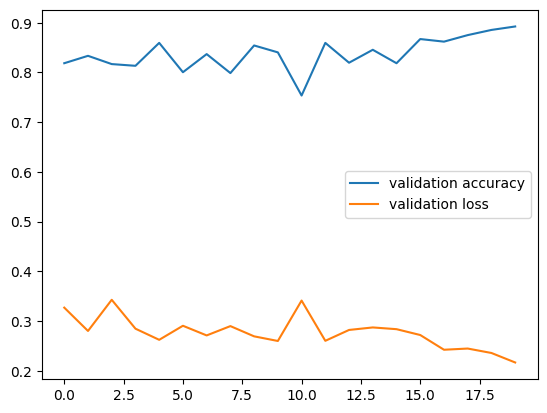

In [31]:
fig = plt.figure(num = 1)
fig2 = fig.add_subplot(1,1,1)
fig2.plot(total_acc_val, label = 'validation accuracy')
fig2.plot(total_loss_val, label = 'validation loss')

plt.legend()
plt.show()

# Evaluation des Performaces

***Visualisation de la précision et de la perte de validation***

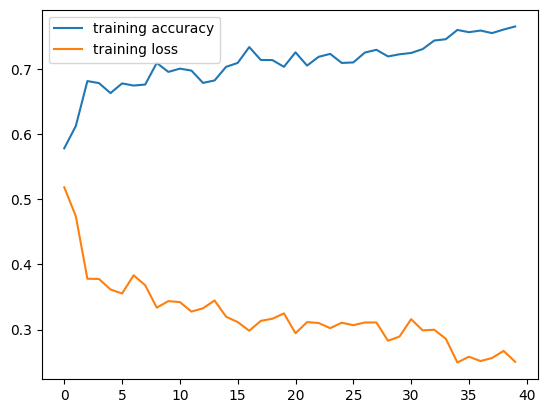

In [32]:
fig = plt.figure(num=1)
fig1 = fig.add_subplot(1,1,1)
fig1.plot(total_acc_train, label = 'training accuracy')
fig1.plot(total_loss_train, label = 'training loss')

plt.legend()
plt.show()

***Visualisation de la précision et de la perte de test***

In [33]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

***Fonction pour afficher la matrice de confusion avec option de normalisation***

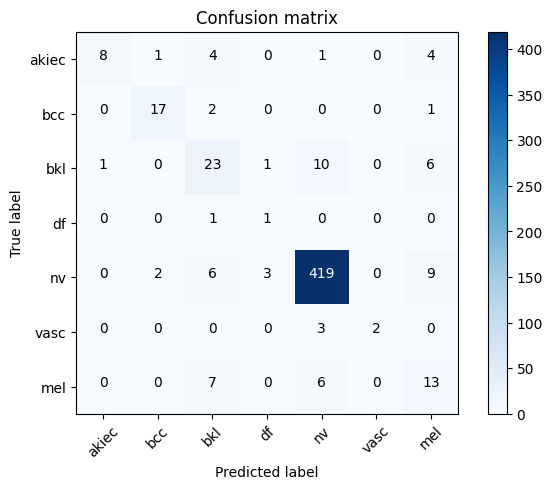

In [34]:
# Validation data evaluation

model.eval()
y_label = []
y_predict = []
with torch.no_grad():
    for i, data in enumerate(val_loader):
        images, labels = data
        N = images.size(0)
        images = Variable(images).to(device)
        outputs = model(images)
        prediction = outputs.max(1, keepdim=True)[1]
        y_label.extend(labels.cpu().numpy())
        y_predict.extend(np.squeeze(prediction.cpu().numpy().T))

# compute the confusion matrix
confusion_mtx = confusion_matrix(y_label, y_predict)
# plot the confusion matrix
plot_labels = ['akiec', 'bcc', 'bkl', 'df', 'nv', 'vasc','mel']
plot_confusion_matrix(confusion_mtx, plot_labels)

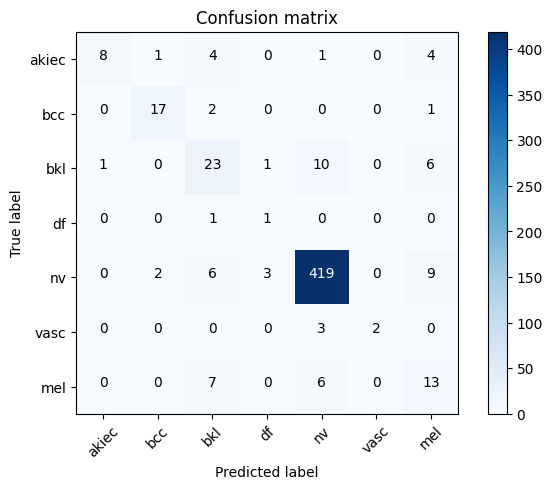

In [35]:
# Test data evaluation

model.eval()
test_y_label = []
test_y_predict = []
with torch.no_grad():
    for i, data in enumerate(test_loader):
        images, labels = data
        N = images.size(0)
        images = Variable(images).to(device)
        outputs = model(images)
        prediction = outputs.max(1, keepdim=True)[1]
        test_y_label.extend(labels.cpu().numpy())
        test_y_predict.extend(np.squeeze(prediction.cpu().numpy().T))

# compute the confusion matrix
confusion_mtx_test = confusion_matrix(test_y_label, test_y_predict)
# plot the confusion matrix
plot_labels = ['akiec', 'bcc', 'bkl', 'df', 'nv', 'vasc','mel']
plot_confusion_matrix(confusion_mtx, plot_labels)

***Évaluation des Données de Validation et Matrice de Confusion***

*****Rapport de classification validation*****

In [36]:
# Generate a validation classification report
report = classification_report(y_label, y_predict, target_names=plot_labels)
print(report)

              precision    recall  f1-score   support

       akiec       0.89      0.44      0.59        18
         bcc       0.85      0.85      0.85        20
         bkl       0.53      0.56      0.55        41
          df       0.20      0.50      0.29         2
          nv       0.95      0.95      0.95       439
        vasc       1.00      0.40      0.57         5
         mel       0.39      0.50      0.44        26

    accuracy                           0.88       551
   macro avg       0.69      0.60      0.61       551
weighted avg       0.89      0.88      0.88       551



*****Rapport de classification test*****

In [37]:
# Generate a test classification report
report = classification_report(test_y_label, test_y_predict, target_names=plot_labels)
print(report)

              precision    recall  f1-score   support

       akiec       0.50      0.50      0.50        12
         bcc       0.85      0.73      0.79        15
         bkl       0.73      0.64      0.68        47
          df       0.40      0.67      0.50         6
          nv       0.97      0.98      0.97       444
        vasc       1.00      0.88      0.93         8
         mel       0.65      0.65      0.65        20

    accuracy                           0.91       552
   macro avg       0.73      0.72      0.72       552
weighted avg       0.92      0.91      0.91       552



***Erreur de Classification par Label - Ensemble Validation***

Text(0, 0.5, 'Fraction classified incorrectly')

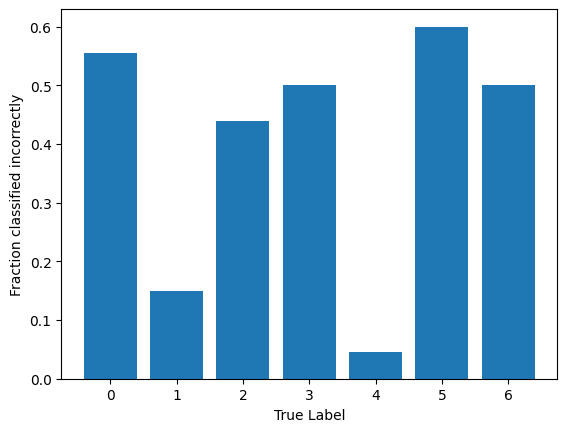

In [38]:
label_frac_error = 1 - np.diag(confusion_mtx) / np.sum(confusion_mtx, axis=1)
plt.bar(np.arange(7),label_frac_error)
plt.xlabel('True Label')
plt.ylabel('Fraction classified incorrectly')

***Erreur de Classification par Label - Ensemble test***

Text(0, 0.5, 'Fraction classified incorrectly')

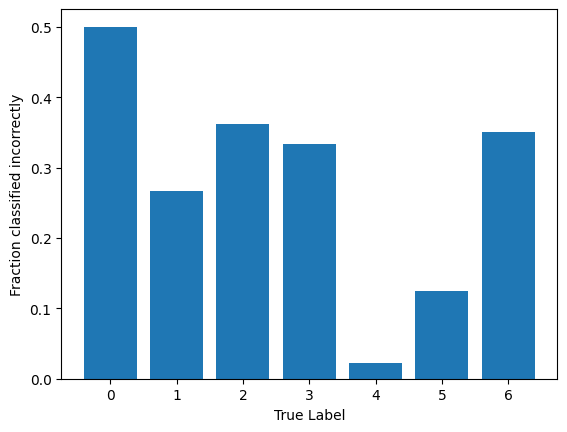

In [39]:
label_frac_error = 1 - np.diag(confusion_mtx_test) / np.sum(confusion_mtx_test, axis=1)
plt.bar(np.arange(7),label_frac_error)
plt.xlabel('True Label')
plt.ylabel('Fraction classified incorrectly')

***La Courbe ROC***

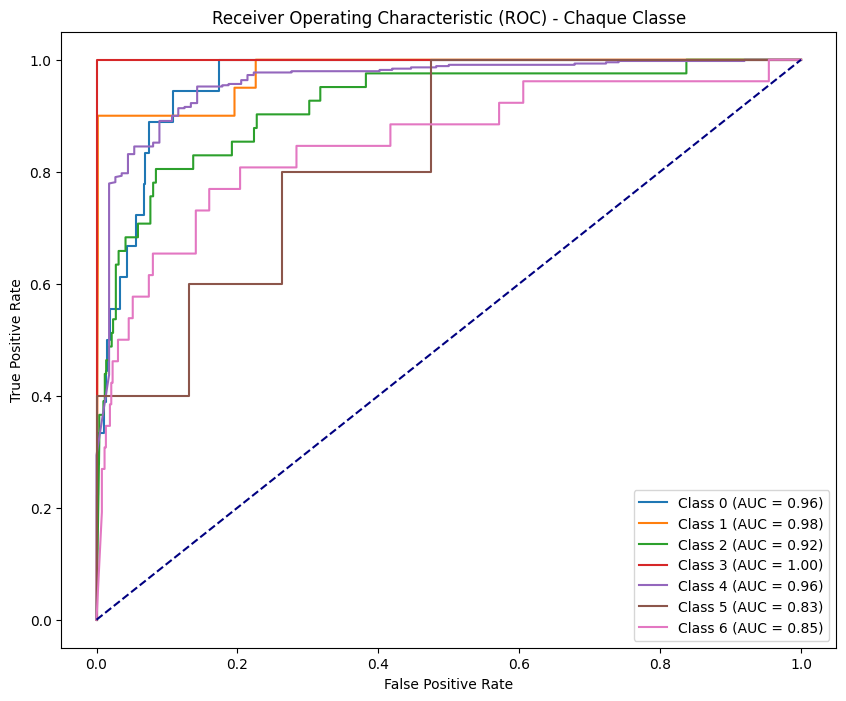

In [40]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import torch
import numpy as np
from sklearn.preprocessing import label_binarize

def plot_roc_for_classes(model, val_loader, num_classes, device):
    """
    Fonction pour tracer la courbe ROC pour chaque classe.
    :param model: Modèle PyTorch.
    :param val_loader: DataLoader pour l'ensemble de validation.
    :param num_classes: Nombre de classes.
    :param device: Le périphérique (GPU ou CPU).
    """
    # Initialisation des labels et des probabilités prédites
    y_true = []
    y_scores = []

    model.eval()  # Mettre le modèle en mode évaluation

    with torch.no_grad():  # Pas besoin de calculer les gradients pendant l'évaluation
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            
            # Passer les images à travers le modèle
            outputs = model(images)
            
            # Calculer les probabilités via softmax
            probabilities = torch.softmax(outputs, dim=1)
            
            # Ajouter les véritables labels et les probabilités prédites
            y_true.extend(labels.cpu().numpy())
            y_scores.extend(probabilities.cpu().numpy())

    # Convertir les labels en format binaire (1 par classe)
    y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))

    # Tracer la courbe ROC pour chaque classe
    plt.figure(figsize=(10, 8))
    for i in range(num_classes):
        # Calculer la courbe ROC
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], np.array([score[i] for score in y_scores]))
        roc_auc = auc(fpr, tpr)
        
        # Tracer la courbe ROC
        plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')
    
    # Tracer la ligne de non-séparation
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')

    # Ajouter les labels et légende
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) - Chaque Classe')
    plt.legend(loc='lower right')

    # Afficher le graphique
    plt.show()

# Exemple d'utilisation (après l'évaluation du modèle)
num_classes = 7  # Nombre de classes dans votre dataset
plot_roc_for_classes(model, val_loader, num_classes, device)


In [41]:
# Sauvegarder le modèle avec les poids après l'entraînement
torch.save(model.state_dict(), '/kaggle/working/model_exp9.pth')